In [4]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [111]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251218-234255'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [112]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [113]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])

In [115]:
# Assume df has columns: ['i', 'cs_j', 'richness']

# For each group (e.g., by 'i'), compute the conditional probability
results = []
for cs_j in range(1, 4):
    for richness in range(5):
        mask_n0 = (df['cs_j'] < cs_j)
        gdf = df.loc[mask_n0].groupby('i').mean().reset_index()
        idxs = gdf.loc[gdf.richness == richness, 'i'].values
        mask_n = (df['cs_j'] == cs_j) & (df['richness'] == richness)& (df['i'].isin(idxs))
        
        n = mask_n.sum()
        n_total = len(idxs)
        results.append([cs_j, richness, n, n_total])
        total_n = (df['cs_j'] == cs_j).sum()
        
cond_prob_df = pd.DataFrame(results, columns= ['cs_j', 'richness', 'n', 'n_total'])

In [116]:
cond_prob_df['P'] = cond_prob_df['n'] / cond_prob_df['n_total']

In [117]:
cond_prob_df

,cs_j,richness,n,n_total,P
0,1,0,1,6,0.166667
1,1,1,30,126,0.238095
2,1,2,153,394,0.388325
3,1,3,118,363,0.325069
4,1,4,17,111,0.153153
5,2,0,0,1,0.000000
6,2,1,31,112,0.276786
7,2,2,105,241,0.435685
8,2,3,74,156,0.474359
9,2,4,9,17,0.529412


In [168]:
pivot = df.pivot_table(index='i', columns='cs_j', values='richness')
import itertools

cols = [0, 1, 2, 3, 4]
all_probs = []
for perm in itertools.permutations(cols):
    pivot.columns = perm
    # Calculate P(richness constant for cs_j ≤ i | richness constant for cs_j < i)
    probs = []
    for i in range(1, 5):
        prev_mask = pivot[list(range(i))].nunique(axis=1) == 1  # richness constant for cs_j < i
        if prev_mask.sum() == 0:
            probs.append(np.nan)
            print(f"P(richness constant for cs_j <= {i} | cs_j < {i}): nan (no cases)")
            continue
        this_mask = pivot[list(range(i + 1))].nunique(axis=1) == 1  # richness constant for cs_j <= i
        prob = (this_mask & prev_mask).sum() / prev_mask.sum()
        probs.append(prob)
        # print(f"P(richness constant for cs_j <= {i} | cs_j < {i}): {prob:.3f}")
    all_probs.append(probs)
    

In [171]:
probdf = pd.DataFrame(all_probs, columns=['P_cs1', 'P_cs2', 'P_cs3', 'P_cs4']).melt(var_name='cs_j', value_name='P')


<Axes: xlabel='cs_j', ylabel='P'>

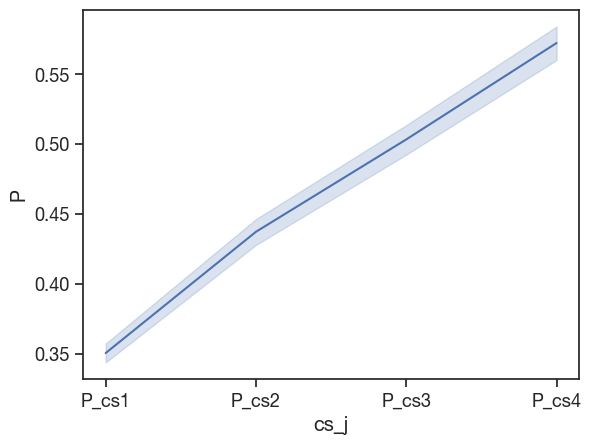

In [174]:
sns.lineplot(data=probdf, x='cs_j', y='P')

In [165]:
probs

[np.float64(0.326),
 np.float64(0.37116564417177916),
 np.float64(0.5619834710743802),
 np.float64(0.6323529411764706)]

In [156]:
pivot['01'] = (pivot[0]==pivot[1])
pivot['12'] = (pivot[1]==pivot[2])
pivot['23'] = (pivot[2]==pivot[3])
pivot['34'] = (pivot[3]==pivot[4])

In [157]:
print(pivot[['01']].all(axis=1).sum()/1000)
print(pivot[['01', '12']].all(axis=1).sum()/pivot[['01']].all(axis=1).sum())
print(pivot[['01', '12', '23']].all(axis=1).sum()/pivot[['01', '12']].all(axis=1).sum())
print(pivot[['01', '12', '23', '34']].all(axis=1).sum()/pivot[['01', '12', '23']].all(axis=1).sum())

0.34
0.4470588235294118
0.4473684210526316
0.6323529411764706


P(richness constant for cs_j <= 1 | cs_j < 1): 0.332
P(richness constant for cs_j <= 2 | cs_j < 2): 0.506
P(richness constant for cs_j <= 3 | cs_j < 3): 0.512
P(richness constant for cs_j <= 4 | cs_j < 4): 0.500


In [118]:
agg_df = cond_prob_df.groupby('cs_j').sum()
agg_df['P'] = agg_df['n'] / agg_df['n_total']

In [119]:
agg_df

,richness,n,n_total,P
cs_j,,,,
1,10,319,1000,0.319000
2,10,219,527,0.415560
3,10,138,361,0.382271


In [103]:
p_df2 = []
for cs_j in range(1, 4):
    mask_n0 = (df['cs_j'] <= cs_j)
    gdf = df.loc[mask_n0].groupby('i').std().reset_index()
    idxs = gdf.loc[gdf.richness == 0, 'i'].values
    p_df2.append([cs_j, len(idxs), args.N, len(idxs)/args.N])
pd_df2 = pd.DataFrame(p_df2, columns=['cs_j', 'n', 'n tot', 'P'])

In [104]:
cond_prob_df

,cs_j,richness,n,n_total,P
0,1,0,0,0,NaN
1,1,1,0,9,0.000000
2,1,2,4,16,0.250000
3,1,3,8,19,0.421053
4,1,4,3,6,0.500000
5,2,0,0,0,NaN
6,2,1,0,5,0.000000
7,2,2,3,5,0.600000
8,2,3,2,11,0.181818
9,2,4,1,3,0.333333


In [152]:
st.pearsonr(pivot[4], pivot[0])

PearsonRResult(statistic=np.float64(0.24345890686534905), pvalue=np.float64(5.857567461539789e-15))